In [27]:
#%config InlineBackend.figure_formats=['svg']
# Generic import 
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
# Train a model
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.utils.plot import load_run_results
# Define clustering
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture

from matplotlib.pyplot import cm

### Train a model

The first step is to choose an autoencoder architecture from the available options and optimize its hyperparameters.
The optimization can be done using the `sweep` method (futur document will be written on hyperparameter optimization).
The optimal architecture and parameters are case dependant but a simple architecture appears to be enough for most cases.

In [28]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST (250) train",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250, 
        },
'network' : {
        'activation_list'          : ['GELU', 'GELU', 'PReLU', 'GELU', 'GELU'],
        'layer_list'               : [200, 100, 50, 1, 50, 100, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', 
        'alpha'                    : 0.002,
        'epochs'                   : 6,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-6
        }
}

With the proper config dictionnary it is now possible to run an experiment and train our network.
A `run` folder with the date and time will be created in the specified path.

In [29]:
autoencoder = recurrentTriplet()
#autoencoder.run(run_config_Triplet)

It is possible to directly analyse our results through the `load_run_results` function.

In [30]:
#load_run_results("AutoencoderLog/run-2023-10-01-09-41", [0.01])

### Define clustering

If the autoencoder successfully accomplishes its intended task it is possible to fit our training data using a clustering method.
In this case th K-Means method is used since it is easily scalable.

First import the set on which the clustering is trained on.

In [31]:
signal_size = 30_000
path_test = r"/home/nicolasdc/files/Single-Photon-Detection/src/Datasets/SNSPD/Paderborn/data/"

#X_test = np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[:,3250:4500] for fileName in listdir(path_test)])
#X_test = X_test.astype("double")
#X_test = (X_test - np.mean(X_test))/np.std(X_test)
#X_test = X_test[np.min(X_test, axis=1) < 0]
#X_test = X_test[np.max(X_test, axis=1) > 1]

#X_train = X_test

In [32]:
signal_size = 250
path_test = r'Datasets/TES/NIST (250) test/'
path_train = r'Datasets/TES/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

In [33]:
#agm = autoencoder_gaussianMixture('AutoencoderLog/grid-search-SNPSD tanh/run 32/fold 0')
agm = autoencoder_gaussianMixture('AutoencoderLog/grid-search-TES param/run 13/fold 0')

Train the kernel density and gaussian mixture and define the interval of possible number of cluster

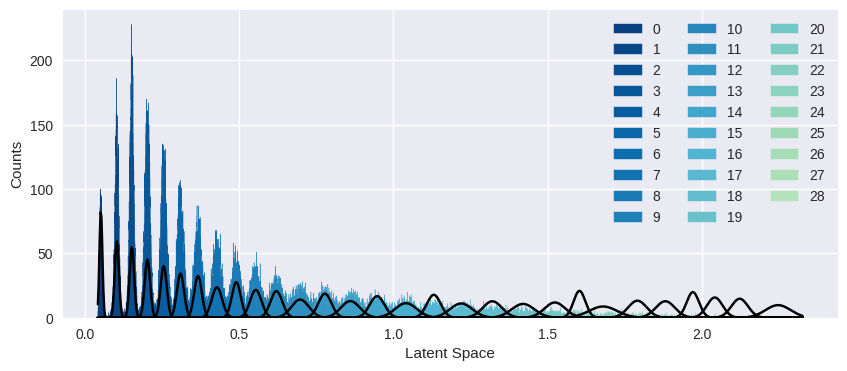

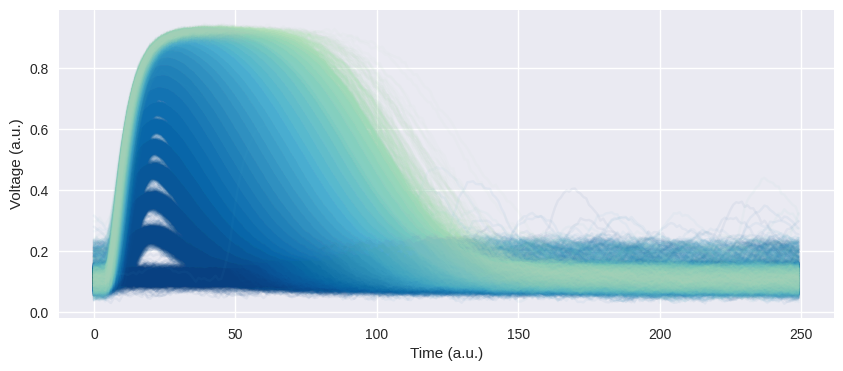

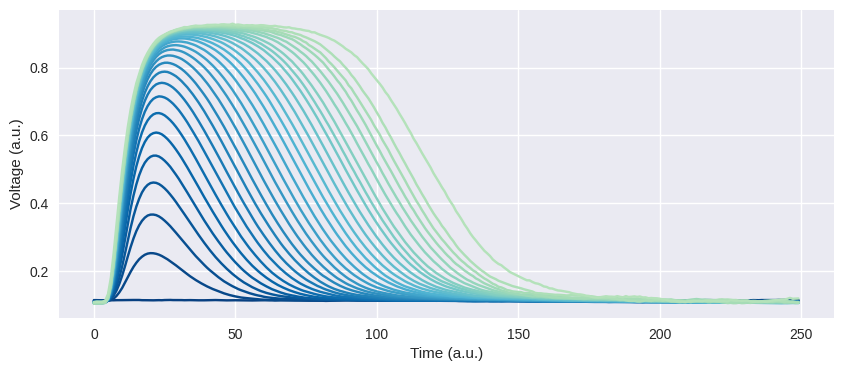

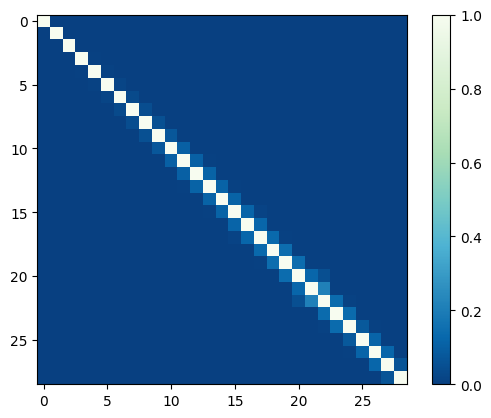

In [34]:
agm.fit(np.copy(X_train),
        bins_plot = 5_000,
        plot_cluster = True,
        plot_traces = True,
        plot_traces_average = True,
        plot_cross_talk = True,
        bw_cst = [0.014],#[0.0065],
        filter_input = False,
        filter_threshold = 0.0004,
        skip = 1,
        flip = True)

In [35]:
clusters_low_dim = agm.get_clusters(np.copy(X_test),
                                    filter_input = True,
                                    filter_threshold = 0.0005)

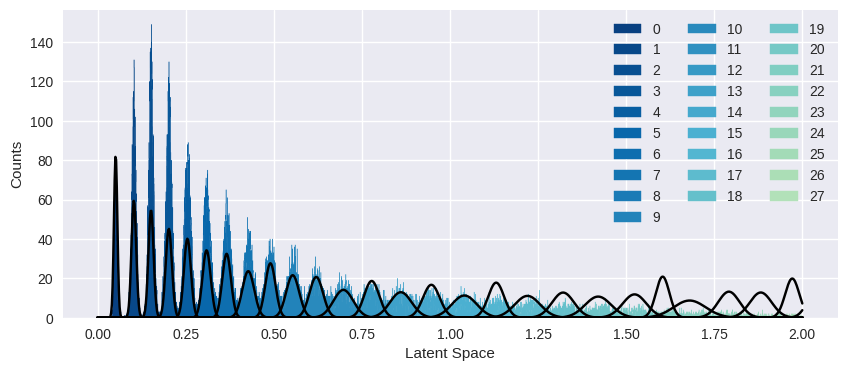

In [40]:
import torch
def gaussian_function(x, mean, variance):
    return (2*np.pi*variance)**(-1/2) * np.exp(-(x - mean)**2/(2*variance))

min_ = 0#torch.min(clusters_low_dim[0])
max_ = 2#torch.max(clusters_low_dim[-1])
bins = np.linspace(min_, max_, 5000)

x = np.linspace(min_, max_, 1000).reshape(-1,1)
n =len(clusters_low_dim)
color = iter(cm.GnBu_r(np.linspace(0, 1, int(1.5*n))))

#with plt.rc_context({'axes.edgecolor':'white', 'xtick.color':'white', 'ytick.color':'white', 'figure.facecolor':'white'}):
with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10,4)) #, dpi=100
    for index_cluster, cluster in enumerate(clusters_low_dim):
        c = next(color)
        plt.hist(-1*cluster , bins, label=f"{index_cluster}", fill=True, histtype='step',color=c)#"#8dd3c7")
    for index, mean_value in enumerate(agm.cluster_means):
        plt.plot(x, gaussian_function(x, mean_value, agm.cluster_covariance[index]), color="k")
    plt.xlabel("Latent Space")
    plt.ylabel("Counts")

    plt.legend(ncol=3)
    plt.show()

### From traces to labels

The `autoencoder_object` is now trained and initialized, it is possible to get the label of new traces by using the `get_label` function.

In [37]:
from timeit import default_timer as timer

In [44]:
X = X_test
start = timer()
lab = agm.get_label_filter(X)
end = timer()

print("Number of traces : ", len(X))
print("Number of traces per second : ",int(len(X) / (end - start)))

Number of traces :  71680
Number of traces per second :  833945


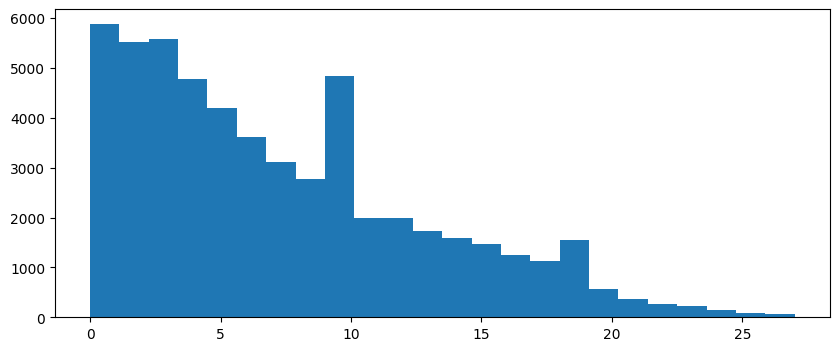

In [39]:
plt.figure(figsize=(10,4), dpi=100)
plt.hist(lab.view(-1), bins=24)
plt.show()